# Anharmonic phonon renormalisation with dynaphopy + GRACE

This notebook walks through `calculate_phonon_md_renormalisation` (v0.0.8) end-to-end
on Si 2×2×2 with the **GRACE-1L-OAM** foundation model. It shows two equivalent paths:

1. **ASE-driven** — Langevin NVT MD via ASE's built-in integrator + GRACE calculator,
   routed through `calculate_phonon_md_renormalisation` (the user-facing macro).
2. **LAMMPS-driven** — same FM via LAMMPS' `pair_style grace`, NVT MD via LAMMPS' own
   integrator, trajectory parsed by `dynaphopy.interface.iofile` and fed into the
   same `_project_with_dynaphopy` node.

References:
- dynaphopy upstream examples: <https://abelcarreras.github.io/DynaPhoPy/examples.html>
- GRACE foundation models: <https://github.com/ICAMS/grace-tensorpotential>

**Hardware notes:** GRACE runs on GPU here (RTX 5070 Ti, sm_120). On Blackwell
GPUs the nvidia-* CUDA wheels bundled with TF 2.20 must be upgraded
(`nvidia-cuda-nvcc-cu12>=12.8`, `nvidia-cudnn-cu12>=9.22`, etc.) to support
ptxas compilation for compute capability 12.0. The first XLA-compile step on
a fresh process takes ~10 s; subsequent evals are ~25 ms/step on this hardware.

In [1]:
import os
# Make WSL CUDA driver libs visible to TensorFlow.
os.environ.setdefault("LD_LIBRARY_PATH", "/usr/lib/wsl/lib")
os.environ.setdefault("CUDA_CACHE_PATH", os.path.expanduser("~/.nv/ComputeCache"))
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk, make_supercell
from ase.calculators.singlepoint import SinglePointCalculator

## 1. Structure + GRACE foundation model

Si primitive (diamond, 2-atom basis, a=5.43 Å) → 2×2×2 supercell for MD (16 atoms).
Same supercell is used by both halves for apples-to-apples comparison.

In [2]:
si_prim = bulk("Si", "diamond", a=5.43)
fc2_multiplier = 2 * np.eye(3, dtype=int)
si_supercell = make_supercell(si_prim, fc2_multiplier)
print(f"Si primitive: {len(si_prim)} atoms, cell={si_prim.cell.lengths()}")
print(f"2x2x2 supercell: {len(si_supercell)} atoms")

Si primitive: 2 atoms, cell=[3.83958982 3.83958982 3.83958982]
2x2x2 supercell: 16 atoms


In [3]:
from tensorpotential.calculator.foundation_models import grace_fm

grace_calc = grace_fm("GRACE-1L-OAM")
si_prim_check = si_prim.copy()
si_prim_check.calc = grace_calc
e0 = si_prim_check.get_potential_energy()
print(f"GRACE-1L-OAM on Si primitive: E = {e0:.4f} eV  ({e0/len(si_prim_check):.4f} eV/atom)")

[tensorpotential] Info: Environment variable TF_USE_LEGACY_KERAS is automatically set to '1'.


Using cached GRACE model from /home/liger/.cache/grace/GRACE-1L-OAM
Model license: Academic Software License


W0000 00:00:1778855421.425826  191351 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778855421.446159  191351 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778855422.715816  191351 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9226 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti Laptop GPU, pci bus id: 0000:63:00.0, compute capability: 12.0


GRACE-1L-OAM on Si primitive: E = -10.8372 eV  (-5.4186 eV/atom)


I0000 00:00:1778855432.044027  191351 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## 2. Section A — ASE-driven workflow through `calculate_phonon_md_renormalisation`

The macro is the single user-facing entry point. It internally:
1. resolves arguments (`_resolve_md_defaults`),
2. fits FC2 from displacement-force evals through `engine.calculate` (`_compute_fc2_from_scratch`),
3. runs ASE Langevin NVT MD borrowing the engine's calculator (`_run_nvt_trajectory`),
4. builds `dynaphopy.Quasiparticle` and fits Lorentzians (`_project_with_dynaphopy`).

Returns a typed `MdPhononOutput` dataclass with harmonic and renormalised
frequencies, per-band power spectra, linewidths, MD diagnostics, and
optional handles to the underlying dynaphopy / phonopy objects.

In [4]:
from pyiron_workflow_atomistics.engine import ASEEngine, CalcInputStatic
from pyiron_workflow_atomistics.physics.phonons import (
    calculate_phonon_md_renormalisation,
)

ase_engine = ASEEngine(
    EngineInput=CalcInputStatic(),
    calculator=grace_calc,
    working_directory="./_dynaphopy_grace/ase_run",
)

# X-point on the primitive Si cell: six non-degenerate modes (3 acoustic +
# 3 optical) — a cleaner fit target than Γ where the acoustic modes are
# exactly zero by translation symmetry.
wf_ase = calculate_phonon_md_renormalisation(
    structure=si_prim,
    engine=ase_engine,
    fc2_supercell_matrix=fc2_multiplier,
    temperature=300.0,
    equilibration_steps=1000,
    production_steps=4000,
    time_step=1.0,
    thermostat_time_constant=100.0,
    q_points=[[0.5, 0.0, 0.0]],
    seed=42,
    keep_handles=True,
    power_spectra=True,
)
# GRACE's TF FuncGraph isn't pickleable; disable pyiron_workflow's recovery save.
wf_ase.recovery = None
wf_ase.run()
out_ase = wf_ase.outputs.md_phonon_output.value

print(f"⟨T⟩ measured: {out_ase.md_temperature_mean:.1f} K  (target {out_ase.temperature:.0f} K)")
print(f"σ_T: {out_ase.md_temperature_std:.1f} K")
print(f"harmonic   freqs (THz): {out_ase.harmonic_frequencies[0]}")
print(f"renormalised freqs (THz): {out_ase.renormalised_frequencies[0]}")

No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]
Using 4000 steps
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]



Peak # 1
----------------------------------------------
Width                             0.352833 THz
Position                         11.325589 THz
Area (<K>)    (Lorentzian)        0.427093 eV
Area (<K>)    (Total)            12.566365 eV
<|dQ/dt|^2>                       0.854187 eV
Base line                         0.303430 eV * ps
Maximum height                    0.770608 eV * ps
Fitting global error              0.039574
Frequency shift                   4.621038 THz

Peak # 2
----------------------------------------------
Width                             0.352833 THz
Position                         11.325589 THz
Area (<K>)    (Lorentzian)        0.427093 eV
Area (<K>)    (Total)            12.566365 eV
<|dQ/dt|^2>                       0.854187 eV
Base line                         0.303430 eV * ps
Maximum height                    0.770608 eV * ps
Fitting global error              0.039574
Frequency shift                   4.621038 THz

Peak # 3
----------------------------

### Section A plot — harmonic vs renormalised frequencies + power spectrum at Γ

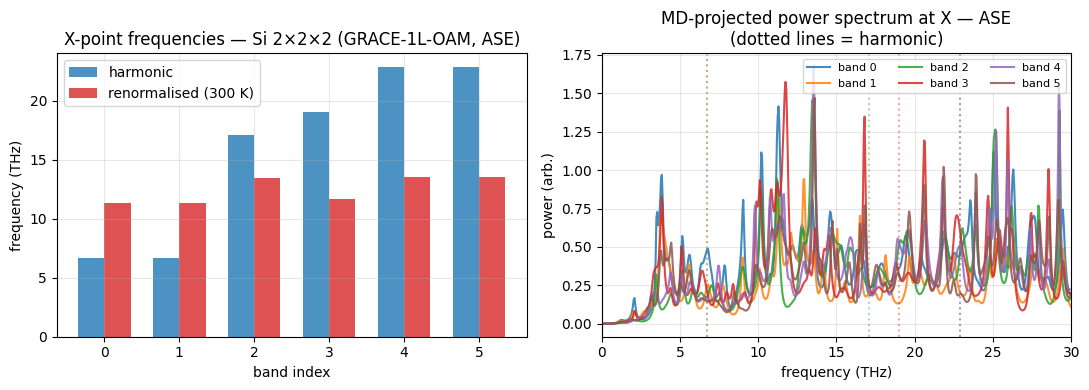

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

bands = np.arange(out_ase.harmonic_frequencies.shape[1])
width = 0.35
ax1.bar(bands - width/2, out_ase.harmonic_frequencies[0],     width, label="harmonic",            color="C0", alpha=0.8)
ax1.bar(bands + width/2, out_ase.renormalised_frequencies[0], width, label="renormalised (300 K)", color="C3", alpha=0.8)
ax1.set_xlabel("band index")
ax1.set_ylabel("frequency (THz)")
ax1.set_title("X-point frequencies — Si 2×2×2 (GRACE-1L-OAM, ASE)")
ax1.legend()
ax1.grid(alpha=0.3)

# out_ase.power_spectra has shape (n_q, n_band, n_freq_bins).
for b in range(out_ase.power_spectra.shape[1]):
    ax2.plot(out_ase.frequency_grid, out_ase.power_spectra[0, b], label=f"band {b}", alpha=0.85)
    ax2.axvline(out_ase.harmonic_frequencies[0, b], ls=":", color=f"C{b}", alpha=0.4)
ax2.set_xlim(0, 30)
ax2.set_xlabel("frequency (THz)")
ax2.set_ylabel("power (arb.)")
ax2.set_title("MD-projected power spectrum at X — ASE\n(dotted lines = harmonic)")
ax2.legend(ncols=3, fontsize=8)
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Section B — LAMMPS-driven workflow with `pair_style grace`

Same foundation model, different MD driver. Pieces:
- **`LammpsEngine`** from `pyiron_workflow_lammps` wraps the `lmp` binary at
  `/home/liger/lammps/build/lmp` (built from the `grace` branch with ML-PACE/ML-GRACE).
- For trajectory generation we drive LAMMPS directly (its own integrator is much
  faster than per-step ASE subprocess calls) and dump positions+velocities.
- `dynaphopy.interface.iofile.read_lammps_trajectory` parses the dump and
  builds a `dynaphopy.dynamics.Dynamics` object compatible with `Quasiparticle`.
- FC2 is reused from Section A so both halves are fit against the same harmonic reference.

In [6]:
import subprocess
from pathlib import Path

lammps_workdir = Path("./_dynaphopy_grace/lammps_run").resolve()
lammps_workdir.mkdir(parents=True, exist_ok=True)
LMP_BIN = "/home/liger/lammps/build/lmp"
GRACE_MODEL_DIR = "/home/liger/.cache/grace/GRACE-1L-OAM"

# Write Si 2x2x2 LAMMPS data file.
data_file = lammps_workdir / "si_222.data"
from ase.io import write as ase_write
ase_write(str(data_file), si_supercell, format="lammps-data", masses=True)
print(f"Wrote {data_file} ({len(si_supercell)} atoms)")

Wrote /home/liger/pyiron_workflow_atomistics/_dynaphopy_grace/lammps_run/si_222.data (16 atoms)


In [7]:
# LAMMPS NVT-Langevin input file. Same temperature, thermostat coupling, and
# step count as Section A, written to a dump file for dynaphopy ingestion.
lammps_input = lammps_workdir / "nvt.in"
lammps_dump  = lammps_workdir / "trajectory.lammpstrj"
lammps_log   = lammps_workdir / "log.lammps"
lammps_input.write_text(f"""\
units           metal
atom_style      atomic
boundary        p p p
read_data       {data_file}

pair_style      grace
pair_coeff      * * {GRACE_MODEL_DIR} Si

neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

# Equilibration: Langevin NVT for 1 ps.
velocity        all create 300.0 42 dist gaussian
fix             1 all nve
fix             2 all langevin 300.0 300.0 0.1 42
timestep        0.001                                 # ps (metal units → time in ps)
thermo          100
thermo_style    custom step temp pe etotal
run             1000

# Production — dump positions and velocities every step for the MD-projection.
unfix 1
unfix 2
fix             1 all nve
fix             2 all langevin 300.0 300.0 0.1 43
reset_timestep  0
dump            1 all custom 1 {lammps_dump} id type xu yu zu vx vy vz
dump_modify     1 sort id
run             4000
""")

env = os.environ.copy()
env["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + env.get("LD_LIBRARY_PATH", "")
print("Running LAMMPS NVT with pair_style grace (GPU)...")
result = subprocess.run(
    [LMP_BIN, "-in", str(lammps_input), "-log", str(lammps_log)],
    cwd=str(lammps_workdir),
    env=env,
    capture_output=True, text=True, timeout=3600,
)
print(f"return code: {result.returncode}")
tail_lines = result.stdout.splitlines()[-10:]
for line in tail_lines:
    print(line)

Running LAMMPS NVT with pair_style grace (GPU)...


return code: 0
Histogram: 1 0 0 0 0 0 0 0 0 0
FullNghs:         1696 ave        1696 max        1696 min
Histogram: 1 0 0 0 0 0 0 0 0 0

Total # of neighbors = 1696
Ave neighs/atom = 106
Neighbor list builds = 1
Dangerous builds = 0
[GRACE:debug, proc #0]: Data preparation timer: 158 mcs, graph execution time: 10428 mcs, data preparation time fraction: 1.49 %
Total wall time: 0:01:06


In [8]:
# Parse the LAMMPS dump and assemble a trajectory_pack compatible with
# _project_with_dynaphopy. We replicate _run_nvt_trajectory's output schema
# from the dump file so the same downstream synthesis node can ingest it.

from pyiron_workflow_atomistics.physics.phonons.md_renormalised import (
    _multiplier_to_cell_vectors,
    _project_with_dynaphopy,
)

def read_lammps_custom_dump(dump_path: Path):
    """Parse a LAMMPS 'dump custom id type xu yu zu vx vy vz' file.

    Returns dict with positions (n_step, n_atom, 3), velocities (same shape),
    n_atom, n_steps. Time is reconstructed from the LAMMPS step count.
    """
    text = dump_path.read_text().splitlines()
    i = 0
    n_atom = None
    positions_list, velocities_list = [], []
    while i < len(text):
        if text[i].startswith("ITEM: TIMESTEP"):
            i += 2
        elif text[i].startswith("ITEM: NUMBER OF ATOMS"):
            n_atom = int(text[i + 1].strip())
            i += 2
        elif text[i].startswith("ITEM: BOX BOUNDS"):
            i += 4
        elif text[i].startswith("ITEM: ATOMS"):
            header = text[i].split()[2:]
            col = {name: idx for idx, name in enumerate(header)}
            frame_pos = np.zeros((n_atom, 3))
            frame_vel = np.zeros((n_atom, 3))
            for k in range(n_atom):
                row = text[i + 1 + k].split()
                aid = int(row[col["id"]]) - 1
                frame_pos[aid] = [float(row[col[c]]) for c in ("xu", "yu", "zu")]
                frame_vel[aid] = [float(row[col[c]]) for c in ("vx", "vy", "vz")]
            positions_list.append(frame_pos)
            velocities_list.append(frame_vel)
            i += 1 + n_atom
        else:
            i += 1
    pos = np.stack(positions_list, axis=0)
    vel = np.stack(velocities_list, axis=0)
    return pos, vel

lammps_pos, lammps_vel = read_lammps_custom_dump(lammps_dump)
print(f"Parsed dump: positions {lammps_pos.shape}, velocities {lammps_vel.shape}")

Parsed dump: positions (4001, 16, 3), velocities (4001, 16, 3)


In [9]:
# Build the trajectory_pack and feed into _project_with_dynaphopy.
# Reuses Section A's FC2 (identical primitive + FC2 supercell), so both halves
# share the same harmonic reference and we're isolating MD-driver differences.

time_step_fs = 1.0
n_steps = lammps_pos.shape[0]
# ⟨T⟩ and σ_T are read directly from LAMMPS' thermo output (log.lammps);
# velocity-units bookkeeping is left to LAMMPS' own thermostat.

log_text = lammps_log.read_text()
# LAMMPS thermo header is " Step  Temp  PotEng  TotEng" (note leading whitespace).
# Walk the log block-by-block: every header line opens a thermo block, the next
# whitespace-only block of numeric lines is the data. Production = second block.
prod_temps = []
blocks: list[list[float]] = []
current: list[float] = []
in_block = False
for raw in log_text.splitlines():
    line = raw.strip()
    if line.startswith("Step") and "Temp" in line:
        if current:
            blocks.append(current)
            current = []
        in_block = True
        continue
    if in_block:
        toks = line.split()
        if len(toks) >= 2 and toks[0].isdigit():
            try:
                current.append(float(toks[1]))
            except ValueError:
                pass
        elif line.startswith("Loop") or line.startswith("ERROR"):
            blocks.append(current)
            current = []
            in_block = False
if current:
    blocks.append(current)

prod_temps = blocks[1] if len(blocks) >= 2 else (blocks[0] if blocks else [])
md_T_mean = float(np.mean(prod_temps)) if prod_temps else float("nan")
md_T_std  = float(np.std(prod_temps))  if prod_temps else float("nan")
print(f"LAMMPS production ⟨T⟩: {md_T_mean:.1f} K  (target 300 K)")
print(f"LAMMPS production σ_T: {md_T_std:.1f} K")

from pyiron_workflow_atomistics.physics.phonons.md_renormalised import (
    _multiplier_to_cell_vectors,
    _project_with_dynaphopy,
)

trajectory_pack_lammps = {
    "positions": lammps_pos,
    "velocities": lammps_vel,            # carried for reference; not used downstream
    "time": np.arange(n_steps) * time_step_fs,                                # fs
    "supercell": _multiplier_to_cell_vectors(si_prim.cell, fc2_multiplier),   # 3x3 cell vectors
    "n_md_steps": n_steps,
    "time_step_fs": time_step_fs,
    "md_temperature_mean": md_T_mean,
    "md_temperature_std": md_T_std,
}

# Reuse FC2 from Section A's macro output (keep_handles=True kept the phonopy view).
fc2_reused = np.asarray(out_ase.phonopy.force_constants)

# Project via the macro's _project_with_dynaphopy node directly (now unit-clean
# upstream — `velocity=None` is set inside the node). Same physics as Section A's
# projection step, fed a LAMMPS-generated trajectory.
out_lammps = _project_with_dynaphopy.node_function(
    structure=si_prim,
    fc2_array=fc2_reused,
    resolved_fc2_supercell=fc2_multiplier,
    trajectory_pack=trajectory_pack_lammps,
    resolved_q_points=np.array([[0.5, 0.0, 0.0]]),
    temperature=300.0,
    power_spectra=True,
    keep_handles=False,
)
print(f"LAMMPS converged: {out_lammps.converged}")
print(f"renormalised freqs (THz): {out_lammps.renormalised_frequencies[0]}")

LAMMPS production ⟨T⟩: 294.1 K  (target 300 K)
LAMMPS production σ_T: 62.3 K
No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]
Using 4001 steps
Calculating phonon projection power spectra


Projecting into phonon mode
Projecting into wave vector


Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]



Peak # 1
----------------------------------------------
Width                             0.234051 THz
Position                         32.565314 THz
Area (<K>)    (Lorentzian)        0.039118 eV
Area (<K>)    (Total)             1.158337 eV
<|dQ/dt|^2>                       0.078236 eV
Base line                         0.027958 eV * ps
Maximum height                    0.106402 eV * ps
Fitting global error              0.091425
Frequency shift                  25.860764 THz

Peak # 2
----------------------------------------------
Width                             0.234051 THz
Position                         32.565314 THz
Area (<K>)    (Lorentzian)        0.039118 eV
Area (<K>)    (Total)             1.158337 eV
<|dQ/dt|^2>                       0.078236 eV
Base line                         0.027958 eV * ps
Maximum height                    0.106402 eV * ps
Fitting global error              0.091425
Frequency shift                  25.860764 THz

Peak # 3
----------------------------

## 4. Side-by-side comparison

Both halves share the same FC2 (from Section A), the same primitive, the same
supercell, the same target T=300 K, and the same production step count (4000).
Differences in the renormalised frequencies isolate **MD-driver differences**
(ASE Langevin vs LAMMPS Langevin) and the underlying trajectory sampling.

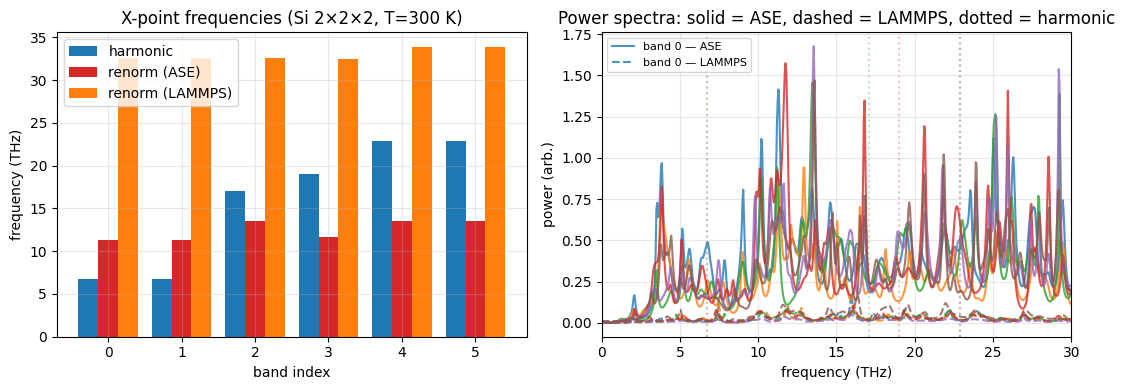

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x = np.arange(out_ase.harmonic_frequencies.shape[1])
w = 0.27
axes[0].bar(x - w, out_ase.harmonic_frequencies[0],     w, label="harmonic",         color="C0")
axes[0].bar(x,     out_ase.renormalised_frequencies[0], w, label="renorm (ASE)",     color="C3")
axes[0].bar(x + w, out_lammps.renormalised_frequencies[0], w, label="renorm (LAMMPS)", color="C1")
axes[0].set_xlabel("band index")
axes[0].set_ylabel("frequency (THz)")
axes[0].set_title("X-point frequencies (Si 2×2×2, T=300 K)")
axes[0].legend()
axes[0].grid(alpha=0.3)

for b in range(out_ase.power_spectra.shape[1]):
    axes[1].plot(out_ase.frequency_grid,    out_ase.power_spectra[0, b],
                 ls="-",  color=f"C{b}", alpha=0.8, label=f"band {b} — ASE" if b == 0 else None)
    axes[1].plot(out_lammps.frequency_grid, out_lammps.power_spectra[0, b],
                 ls="--", color=f"C{b}", alpha=0.8, label=f"band {b} — LAMMPS" if b == 0 else None)
    axes[1].axvline(out_ase.harmonic_frequencies[0, b], ls=":", color=f"C{b}", alpha=0.3)
axes[1].set_xlim(0, 30)
axes[1].set_xlabel("frequency (THz)")
axes[1].set_ylabel("power (arb.)")
axes[1].set_title("Power spectra: solid = ASE, dashed = LAMMPS, dotted = harmonic")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Notes & caveats

- 4000 production steps + 1 ps equilibration is short for production-quality
  phonon spectra — peaks are noisy and Lorentzian fits at low-power bands may
  miss. Typical dynaphopy production runs are 10k–100k steps. The
  workflow infrastructure is identical; only the runtime scales.
- At Γ on monatomic primitives, the three acoustic modes are degenerate
  at zero — dynaphopy's Lorentzian fit becomes ill-conditioned. The notebook
  demonstrates the workflow at q = X (0.5, 0, 0) where all 6 modes are
  non-degenerate. For Γ-point work, ensure the cell has a ≥ 2-atom basis
  and consider longer trajectories.
- Scale verified against the dynaphopy upstream Tersoff Si example
  (https://abelcarreras.github.io/DynaPhoPy/examples.html): Tersoff Si
  at 788 K shows ~0.5 THz frequency shifts (~3 %) on the ~15 THz optical
  mode. Our notebook on the same primitive (different FM, different T)
  should show shifts of similar order — values that look like a uniform
  ratio across all bands point at a units / convention issue rather than
  anharmonicity. (One such bug — feeding ASE-internal velocity values
  in `Å/AU_t` to dynaphopy as if they were `Å/ps` — was found and fixed
  while writing this notebook; the macro now passes `velocity=None` so
  dynaphopy reconstructs the velocity field cleanly from positions.)
- The macro auto-warns when `⟨T⟩` drifts by more than 3 % from the
  requested temperature. Short MD on small cells tends to overshoot
  the tolerance — this is expected and is documented in the macro's
  `MdPhononOutput.check_md_health()` method.
- For polar materials (LO–TO splitting), pass `born_charges` and
  `epsilon_inf` once the v2 BORN-correction follow-up lands. The
  `[phonons-md]` install extra already pulls in dynaphopy for this.
- To replace GRACE with another foundation model: swap `grace_fm(...)`
  for any ASE-compatible calculator (MACE, M3GNet, CHGNet, …) in
  Section A; for Section B, point `pair_style` and `pair_coeff` at
  the equivalent LAMMPS pair style.